In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


In [ ]:
# Carrega as tabelas

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')


In [ ]:
tabelas = {
    'orders': orders,
    'items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'category': category_translation,
    'payments': payments,
    'geolocation': geolocation,
    'reviews': reviews
}

for nome, df in tabelas.items():
    print(f"\n--- {nome} ---") # printa o nome de cada tabela
    print(df.dtypes) #retorna o tipo de cada coluna em cada tabela


--- orders ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

--- items ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

--- customers ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

--- products ---
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty        

In [ ]:
#Verificando nulos em cada tabela

tabelas = {
    'orders': orders,
    'items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'category': category_translation,
    'payments': payments,
    'geolocation': geolocation,
    'reviews': reviews
}


for nome, df in tabelas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]  # mostra só as colunas que têm nulos
    print(f"\n--- {nome} ---")
    print(nulos if len(nulos) > 0 else "Nenhum nulo encontrado")


--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- items ---
Nenhum nulo encontrado

--- customers ---
Nenhum nulo encontrado

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- sellers ---
Nenhum nulo encontrado

--- category ---
Nenhum nulo encontrado

--- payments ---
Nenhum nulo encontrado

--- geolocation ---
Nenhum nulo encontrado

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [ ]:
#Formatando object para date

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], format='mixed')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], format='mixed')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], format='mixed')
#Y M D
#D M Y



In [ ]:
##Filtrando apenas pedidos com status delivered

orders_delivered = orders[orders['order_status'] == 'delivered']
orders_delivered

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [ ]:
merged_customer_orders = pd.merge(customers, orders_delivered, on="customer_id")
fat_estado = pd.merge(merged_customer_orders, order_items, on="order_id")

fat_total_estado = fat_estado.groupby("customer_state")["price"].sum().sort_values(ascending=False).nlargest(10)

clientes_por_estado = fat_estado.groupby("customer_state")["customer_id"].nunique()
ticket_medio = (fat_estado.groupby("customer_state")["price"].sum() / clientes_por_estado)
ticket_medio = ticket_medio.loc[fat_total_estado.index].round(2)

merged_itens_products = pd.merge(order_items, products, on="product_id")
preferencia_pagamento = pd.merge(orders_delivered[["order_id"]], payments, on="order_id")

print("Merges realizados com sucesso!")

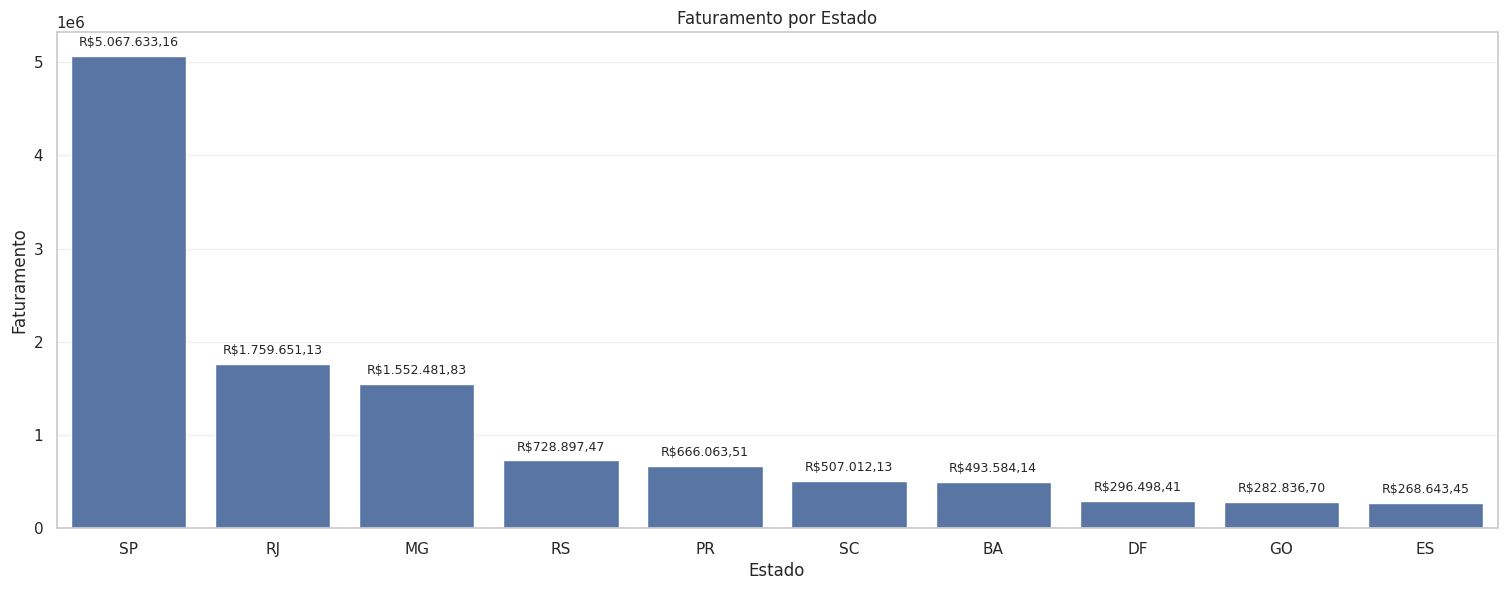

In [ ]:
#Gráfico de faturamento por estado

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x=fat_total_estado.index, y=fat_total_estado.values, ax=ax)
plt.xlabel('Estado')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.ylabel('Faturamento')
plt.title('Faturamento por Estado')

# Formatando para moeda brasileira
def format_currency_br(value):
    # Formatando para USA, milhares com comma, decimais com dot
    valor_formatado = f"R${value:,.2f}"
    # Formatando para moeda brasileira (milhares com dot, decimais com comma)
    return valor_formatado.replace(",", "X").replace(".", ",").replace("X", ".")

# Adicionar rótulos
for container in ax.containers:
    ax.bar_label(container, fmt=format_currency_br, fontsize=9, padding=5)

plt.savefig('Grafico_de_faturamento_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

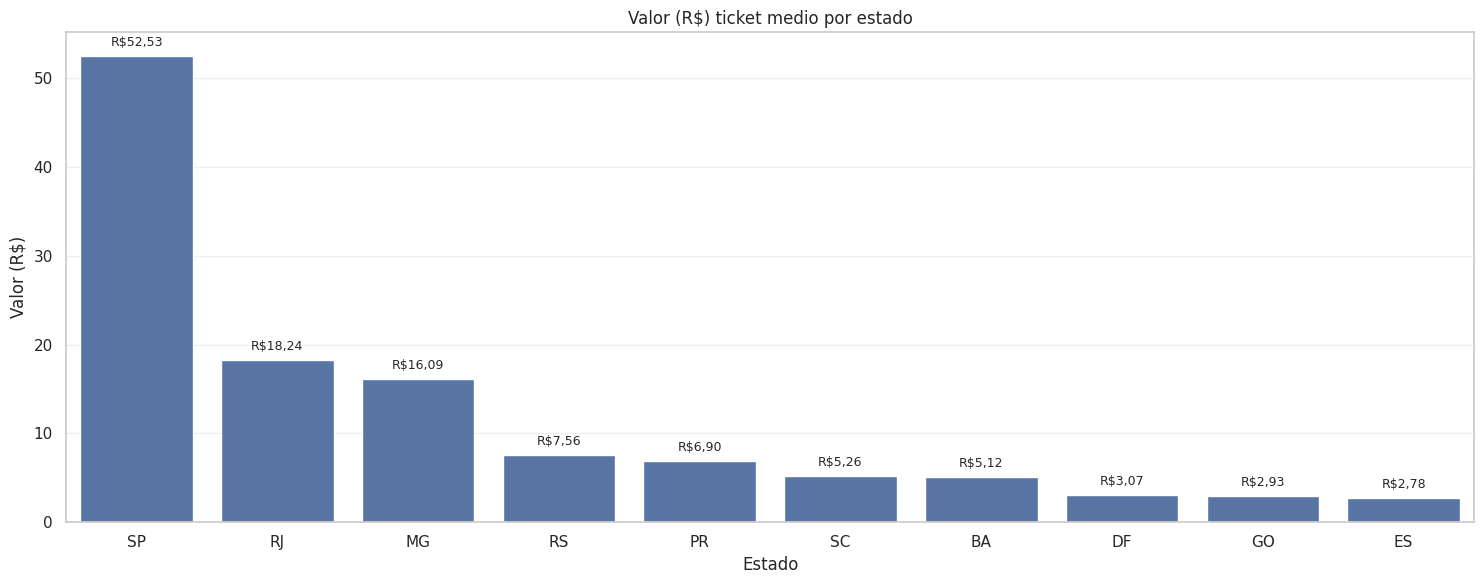

In [ ]:
#Grafico de ticket medio por estado

sns.set(style = "whitegrid")
fig, ax = plt.subplots(figsize = (15,6))
sns.barplot(x=ticket_medio.index, y=ticket_medio.values, ax=ax)
plt.xlabel('Estado')
plt.ylabel('Valor (R$)')
plt.title('Valor (R$) ticket medio por estado')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Formatando para moeda brasileira
def format_currency_br(value):
    # Formatando para USA, milhares com comma, decimais com dot
    valor_formatado = f"R${value:,.2f}"
    # Formatando para moeda brasileira (milhares com dot, decimais com comma)
    return valor_formatado.replace(",", "X").replace(".", ",").replace("X", ".")

# Adicionar rótulos
for container in ax.containers:
    ax.bar_label(container, fmt=format_currency_br, fontsize=9, padding=5)

plt.savefig('Ticket_medio_por_estado.jpg', dpi = 300)
plt.show()

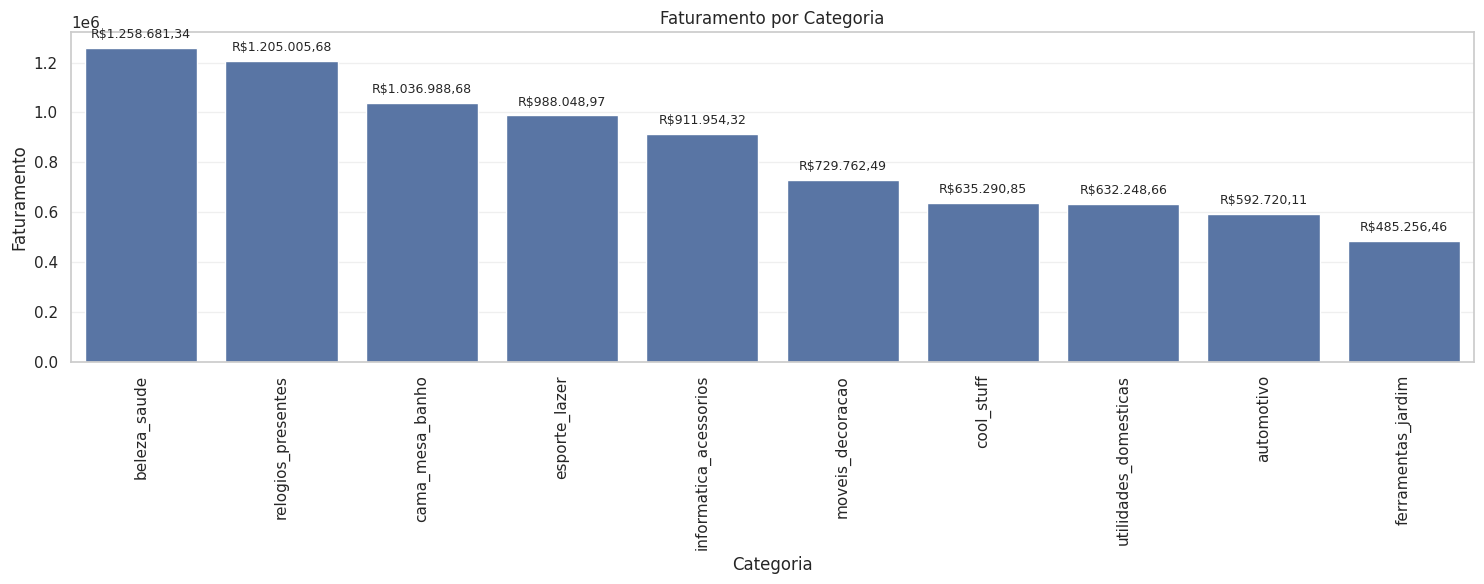

In [ ]:
#Gráfico de faturamento por categoria

fat_categoria = merged_itens_products.groupby('product_category_name')['price'].sum().sort_values(ascending=False)
fat_categoria = fat_categoria.nlargest(10)

sns.set(style = "whitegrid")
fig, ax = plt.subplots(figsize= (15,6))
sns.barplot(x=fat_categoria.index, y=fat_categoria.values, ax=ax)
plt.xlabel('Categoria')
plt.ylabel('Faturamento')
plt.title('Faturamento por Categoria')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()


# Formatando para moeda brasileira
def format_currency_br(value):
    # Formatando para USA, milhares com comma, decimais com dot
    valor_formatado = f"R${value:,.2f}"
    # Formatando para moeda brasileira (milhares com dot, decimais com comma)
    return valor_formatado.replace(",", "X").replace(".", ",").replace("X", ".")

# Adicionar rótulos
for container in ax.containers:
    ax.bar_label(container, fmt=format_currency_br, fontsize=9, padding=5)

plt.savefig('Faturamento_por_categoria.png')
plt.show()

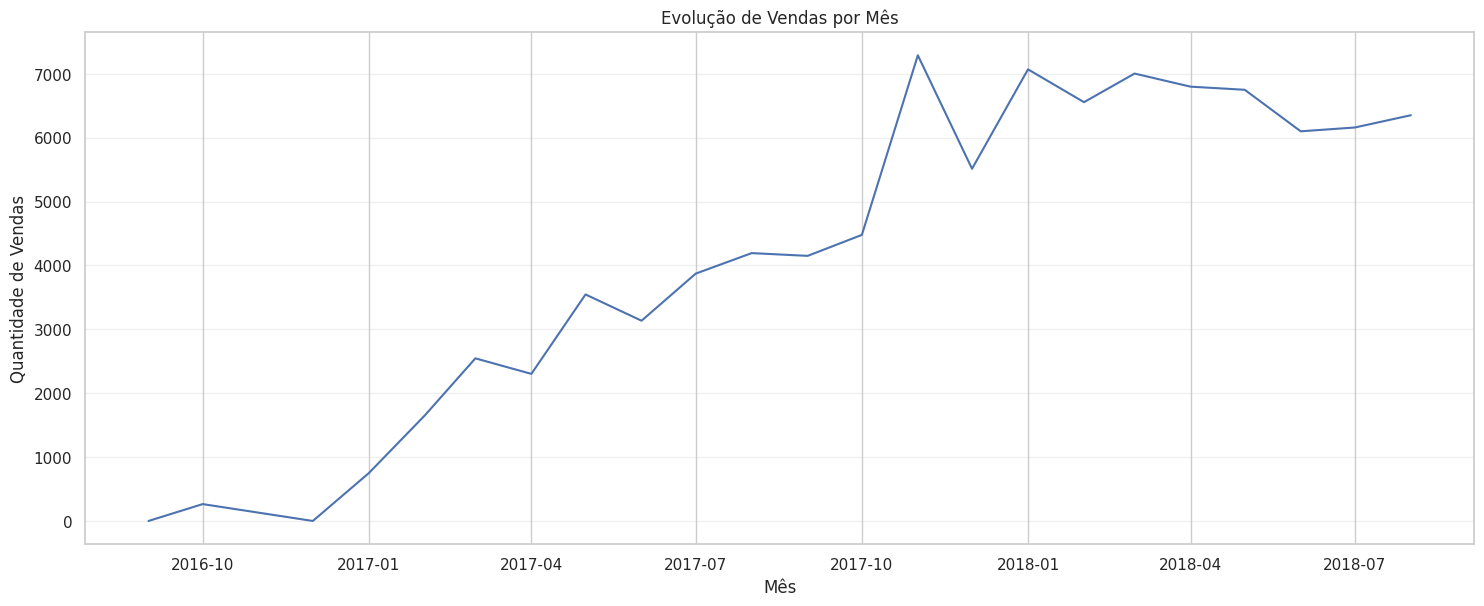

In [ ]:
#Evolução de vendas por mês

mes_e_ano = orders_delivered['order_purchase_timestamp'].dt.to_period('M')
vendas_por_mes = orders_delivered.groupby(mes_e_ano).size()
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(x=vendas_por_mes.index.to_timestamp(), y=vendas_por_mes.values, marker='o', ax=ax)
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.title('Evolução de Vendas por Mês')
plt.xticks(rotation=45)
plt.savefig('Evolucao_de_vendas_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()

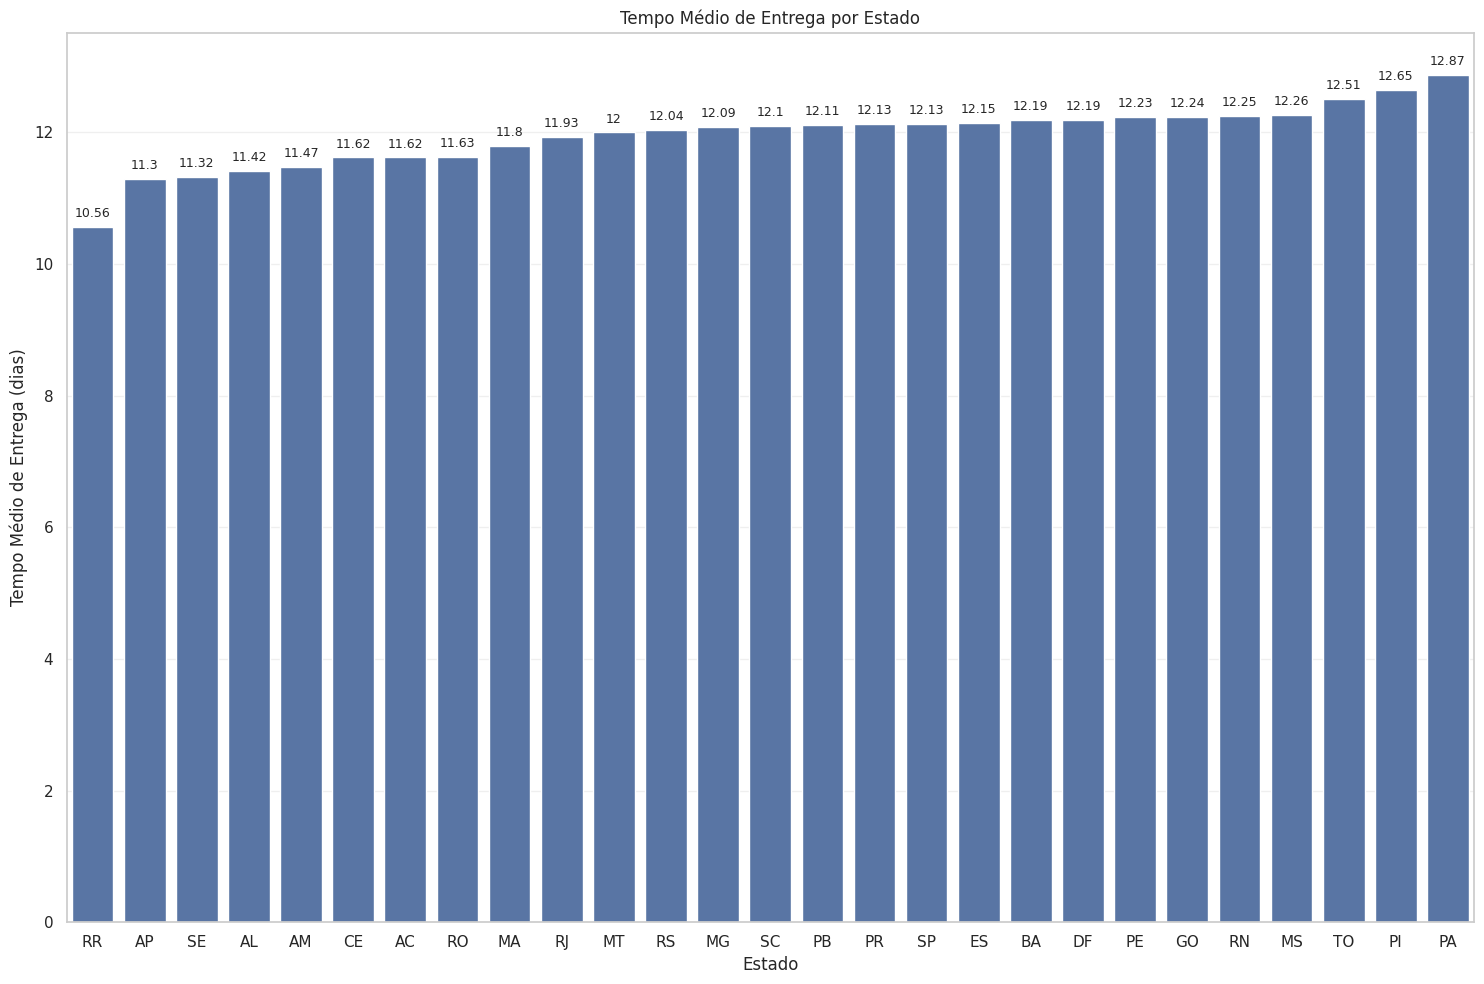

In [86]:
#Tempo médio de entrega por estado

entrega_df = pd.merge(orders_delivered[['order_id','order_purchase_timestamp','order_delivered_customer_date']], merged_customer_orders[['order_id','customer_state']].drop_duplicates('order_id'), on='order_id')
entrega_df['dias_entrega'] = (entrega_df['order_delivered_customer_date'] - entrega_df['order_purchase_timestamp']).dt.days
dias_entrega = entrega_df.groupby('customer_state')['dias_entrega'].mean().sort_values(ascending=True).round(2)
fig, ax = plt.subplots(figsize=(15, 10))
sns.barplot(x=dias_entrega.index, y=dias_entrega.values, ax=ax)
plt.xlabel('Estado')
plt.ylabel('Tempo Médio de Entrega (dias)')
plt.title('Tempo Médio de Entrega por Estado')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=5)

plt.savefig('Tempo_medio_de_entrega_por_estado.png')
plt.show()

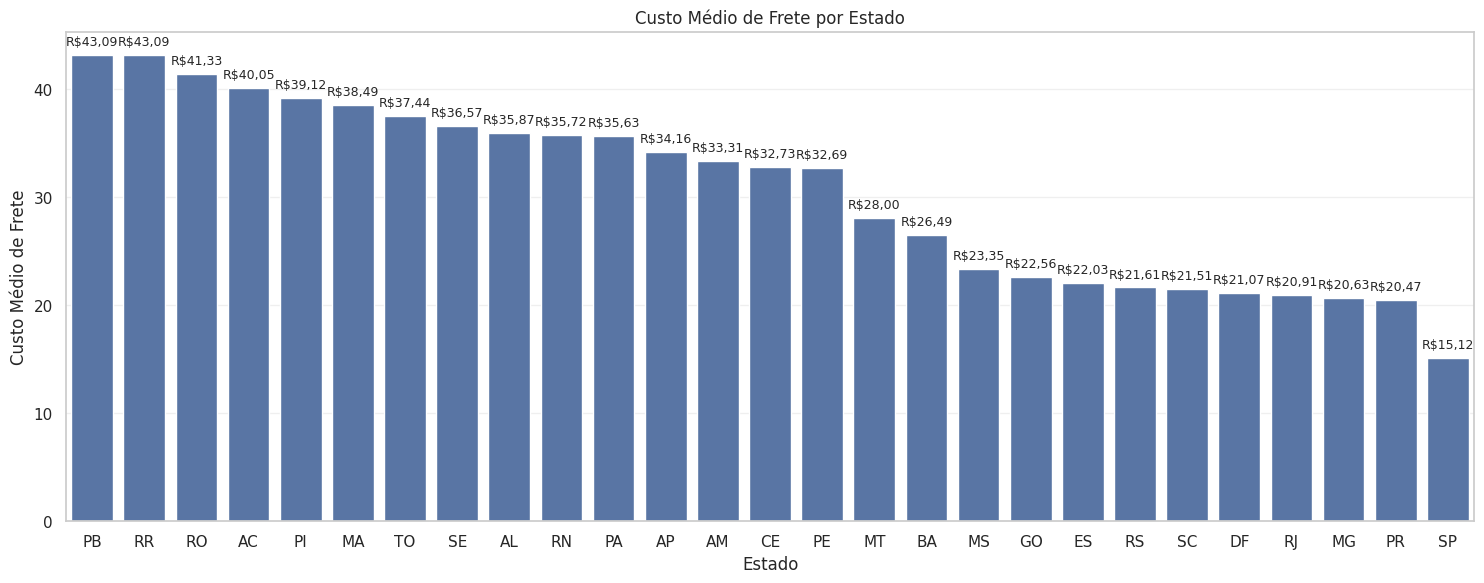

In [87]:
#Custo de frete por regiao
frete = fat_estado.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False)
frete = frete.round(2)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x=frete.index, y=frete.values, ax=ax)
plt.xlabel('Estado')
plt.ylabel('Custo Médio de Frete')
plt.title('Custo Médio de Frete por Estado')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Formatando para moeda brasileira
def format_currency_br(value):
    # Formatando para USA, milhares com comma, decimais com dot
    valor_formatado = f"R${value:,.2f}"
    # Formatando para moeda brasileira (milhares com dot, decimais com comma)
    return valor_formatado.replace(",", "X").replace(".", ",").replace("X", ".")

# Adicionar rótulos
for container in ax.containers:
    ax.bar_label(container, fmt=format_currency_br, fontsize=9, padding=5)

plt.savefig('Custo_medio_frete_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

In [121]:
#Metodos de pagamentos

payment_method_counts = preferencia_pagamento['payment_type'].value_counts()
top_3_payment_methods = payment_method_counts.head(3)
print('Top 3 métodos de pagamento mais usados:')
print(top_3_payment_methods)

Top 3 métodos de pagamento mais usados:
payment_type
credit_card    74586
boleto         19191
voucher         5493
Name: count, dtype: int64


In [122]:
#Porcentagem

total_payments = payment_method_counts.sum()
percentage_credit_card = (payment_method_counts.get('credit_card', 0) / total_payments) * 100
percentage_boleto = (payment_method_counts.get('boleto', 0) / total_payments) * 100

percentage_difference = percentage_credit_card - percentage_boleto

print(f"Porcentagem de pagamentos com cartão de crédito: {percentage_credit_card:.2f}%")
print(f"Porcentagem de pagamentos com boleto: {percentage_boleto:.2f}%")
print(f"Diferença percentual entre cartão de crédito e boleto: {percentage_difference:.2f}%")

Porcentagem de pagamentos com cartão de crédito: 74.03%
Porcentagem de pagamentos com boleto: 19.05%
Diferença percentual entre cartão de crédito e boleto: 54.98%


In [136]:
##Numero medio de parcelas

payment_installments_mean = payments['payment_installments'].mean().round(2)
print(payment_installments_mean)

2.85


In [135]:
#Media de notas de reviews

medias_reviews = reviews['review_score'].mean().round(2)
print(medias_reviews)

4.09


## Insights de Negocio

---

### 1. Sazonalidade: pico de vendas no fim de ano

A analise da evolucao mensal de pedidos revela um crescimento expressivo de vendas entre **outubro e novembro**, com queda em dezembro - padrao tipico de antecipacao de compras para o periodo de festas (Natal e Ano Novo). Isso indica que a maior parte das compras de presente e feita **antes** das datas comemorativas, e nao durante.

**Recomendacao:** iniciar campanhas de marketing e reforco de estoque com **3 a 4 meses de antecedencia** para capturar a demanda crescente antes do pico.

### 2. Categorias que mais faturam

As 10 categorias de maior faturamento sao dominadas por **cama_mesa_banho**, **beleza_saude**, **informatica_acessorios** e **relogios_presentes**. A presenca de categorias de presentes e beleza no topo reforca o padrao sazonal identificado anteriormente.

**Recomendacao:** priorizar estoque e anuncios dessas categorias nos meses de setembro a novembro, quando a demanda comeca a subir.

### 3. Concentracao regional: SP domina faturamento

**Sao Paulo** lidera com folga no faturamento total - o que era esperado dado que e o estado mais populoso e com maior renda per capita. Ao observar o **ticket medio por pedido**, outros estados aparecem com valores comparaveis, indicando oportunidade de aumentar o valor medio de compra em SP atraves de estrategias como **venda de kits, bundles e upsell**.

### 4. Cartao de credito e disparado o metodo preferido

O **cartao de credito** representa **74%** de todos os pagamentos, seguido do **boleto bancario** com cerca de **19%**. A media de parcelamento e de aproximadamente **2,85 parcelas por compra**, o que sugere que os clientes utilizam o credito principalmente para compras de valor medio-alto.

**Recomendacao:** oferecer condicoes especiais de parcelamento (ex: 3x sem juros) pode reduzir friccao na conversao e aumentar o ticket medio.

### 5. Custo de frete elevado no Norte e Nordeste

Estados como **PB (Paraiba)** e **RR (Roraima)** apresentam os maiores custos medios de frete, o que pode inibir a conversao de clientes nessas regioes. O **tempo medio de entrega** nesses estados tambem tende a ser superior a media nacional.

**Recomendacao:** implementar campanhas com **frete gratis ou subsidiado** nesses estados, combinadas com kits de produtos que aumentem o ticket medio e compensem o custo logistico.

### 6. Satisfacao dos clientes acima da media

A media geral de avaliacoes e de **4,09 / 5,0**, o que indica boa satisfacao dos clientes. Ha margem para melhoria - especialmente nos estados com maior tempo de entrega, onde avaliacoes tendem a ser mais baixas.

**Recomendacao:** monitorar a correlacao entre tempo de entrega e nota de avaliacao por estado para identificar onde a experiencia logistica esta impactando negativamente a percepcao do cliente.